In [1]:
!pip install transformers
!pip install torch
!pip install pillow

In [2]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
uploaded = files.upload()

Saving images.jpg to images.jpg


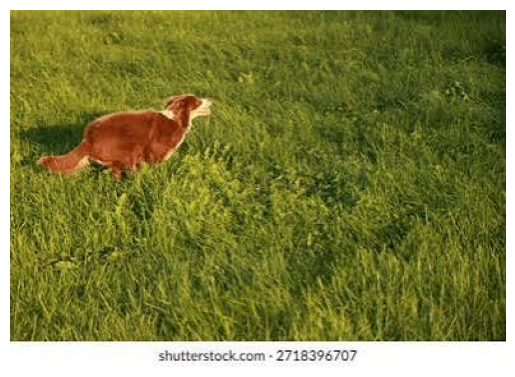

In [4]:
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

In [5]:
processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [6]:
inputs = processor(image, return_tensors="pt")

output = model.generate(**inputs)

caption = processor.decode(output[0], skip_special_tokens=True)

print("Generated Caption:")
print(caption)

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1616: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Generated Caption:
a dog running through a field of grass


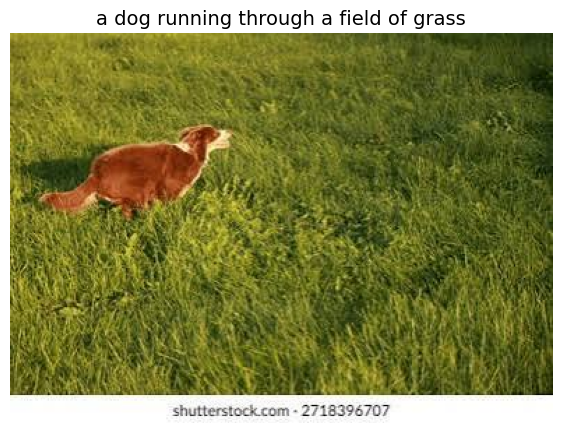

In [7]:
plt.figure(figsize=(7,7))
plt.imshow(image)
plt.title(caption, fontsize=14)
plt.axis("off")
plt.show()